In [27]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/DOHMH_New_York_City_Restaurant_Inspection_Results.csv")

# First 5 rows
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,41395416,STAND 119 MARKET,Queens,126,ROOSEVELT AVENUE,NaN,7185958100,American,09/13/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,4.000000e+00,NaN,NaN
1,50062660,THAISM,Brooklyn,278,SMITH STREET,11231.0,7188340505,Thai,05/20/2025,Establishment re-opened by DOHMH.,...,Cycle Inspection / Reopening Inspection,40.682417,-73.993391,306.0,39.0,7500.0,3006844.0,3.004210e+09,BK33,POINT (-73.993391110412 40.682417248612)
2,50180206,ROOT OF ALL HEALTH,Manhattan,2681,BROADWAY,10025.0,6173047363,NaN,01/01/1900,NaN,...,NaN,40.798580,-73.968931,107.0,6.0,19100.0,1056558.0,1.018748e+09,MN12,POINT (-73.96893112111 40.798579824042)
3,50164459,The Row Harlem juice bar and bowls,Manhattan,2270,ADAM CLAYTON POWELL JR BOULEVARD,NaN,6468797762,NaN,01/01/1900,NaN,...,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
4,50179633,HUDSON CABIN,Manhattan,W,59TH ST COLUMBUS CIRCLE,10023.0,6466372137,NaN,01/01/1900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295912 entries, 0 to 295911
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  295912 non-null  int64  
 1   DBA                    295910 non-null  str    
 2   BORO                   295912 non-null  str    
 3   BUILDING               294942 non-null  str    
 4   STREET                 295892 non-null  str    
 5   ZIPCODE                292839 non-null  float64
 6   PHONE                  295824 non-null  str    
 7   CUISINE DESCRIPTION    292398 non-null  str    
 8   INSPECTION DATE        295912 non-null  str    
 9   ACTION                 292490 non-null  str    
 10  VIOLATION CODE         290049 non-null  str    
 11  VIOLATION DESCRIPTION  290049 non-null  str    
 12  CRITICAL FLAG          295912 non-null  str    
 13  SCORE                  278878 non-null  float64
 14  GRADE                  145992 non-null  str    

In [3]:
# Shape
df.shape

(295912, 27)

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'])

# Fill missing values only in object/text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("Unknown")

# Fill missing values in numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Check again
df.isnull().sum()

C:\Users\syedu\AppData\Local\Temp\ipykernel_19088\3521509827.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


CAMIS                    0
DBA                      0
BORO                     0
BUILDING                 0
STREET                   0
ZIPCODE                  0
PHONE                    0
CUISINE DESCRIPTION      0
INSPECTION DATE          0
ACTION                   0
VIOLATION CODE           0
VIOLATION DESCRIPTION    0
CRITICAL FLAG            0
SCORE                    0
GRADE                    0
GRADE DATE               0
RECORD DATE              0
INSPECTION TYPE          0
Latitude                 0
Longitude                0
Community Board          0
Council District         0
Census Tract             0
BIN                      0
BBL                      0
NTA                      0
Location                 0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


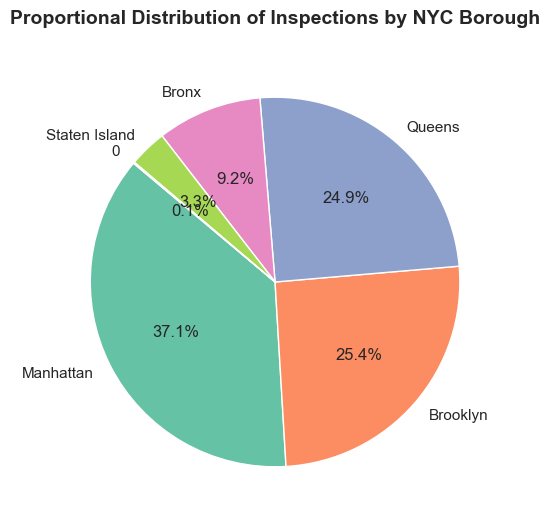

C:\Users\syedu\AppData\Local\Temp\ipykernel_19088\1517825263.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CRITICAL FLAG', palette="Set2", ax=ax2)


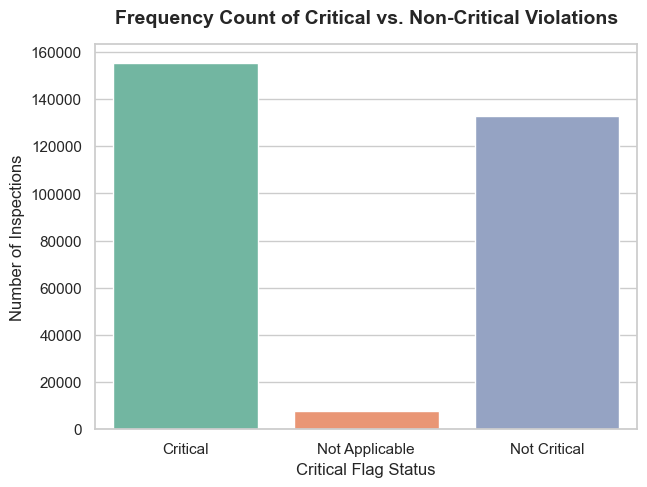

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional color scheme (Required by Guidelines)
sns.set_theme(style="whitegrid")
custom_colors = sns.color_palette("Set2")

# --- CHART 1: PIE CHART (Borough Distribution) ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
boro_counts = df['BORO'].value_counts()

# We drop "Unknown" or "0" rows if they skew the pie chart proportions
if "Unknown" in boro_counts:
    boro_counts = boro_counts.drop("Unknown")

ax1.pie(boro_counts, labels=boro_counts.index, autopct='%1.1f%%', startangle=140, colors=custom_colors)
ax1.set_title("Proportional Distribution of Inspections by NYC Borough", fontsize=14, fontweight='bold', pad=20)
plt.show()

print("\n" + "="*50 + "\n") # Visual separator

# --- CHART 9: COUNT PLOT (Critical Flags) ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='CRITICAL FLAG', palette="Set2", ax=ax2)

ax2.set_title("Frequency Count of Critical vs. Non-Critical Violations", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Critical Flag Status", fontsize=12)
ax2.set_ylabel("Number of Inspections", fontsize=12)
plt.show()

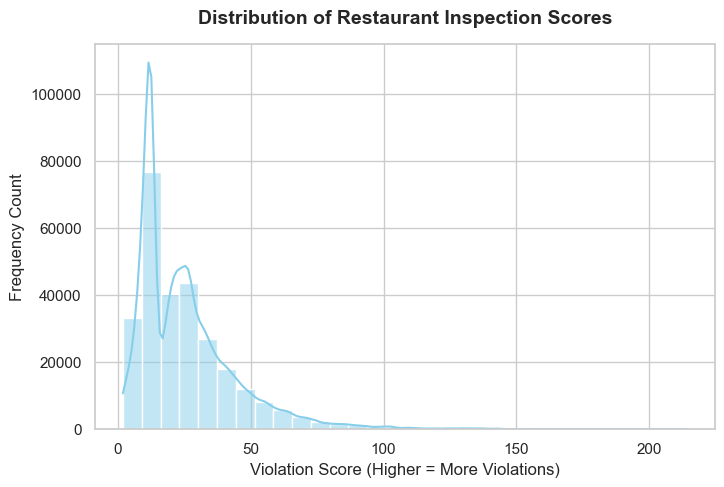

C:\Users\syedu\AppData\Local\Temp\ipykernel_19088\1156753373.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=grade_df, x='GRADE', y='SCORE', palette="Pastel1", order=['A', 'B', 'C'], ax=ax4)


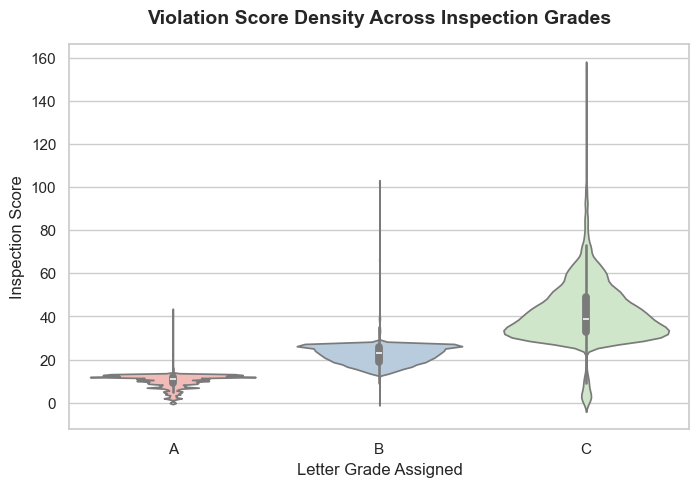

In [29]:
# --- CHART 2: HISTOGRAM (Violation Scores) ---
fig3, ax3 = plt.subplots(figsize=(8, 5))

# Filtering out 0 scores just in case they distort the distribution curve
plot_df = df[df['SCORE'] > 0]

sns.histplot(data=plot_df, x='SCORE', bins=30, kde=True, color='skyblue', ax=ax3)
ax3.set_title("Distribution of Restaurant Inspection Scores", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Violation Score (Higher = More Violations)", fontsize=12)
ax3.set_ylabel("Frequency Count", fontsize=12)
plt.show()

print("\n" + "="*50 + "\n") # Visual separator

# --- CHART 10: VIOLIN PLOT (Grades vs Scores) ---
fig4, ax4 = plt.subplots(figsize=(8, 5))

# Filter to look at standard letter grades A, B, and C
grade_df = df[df['GRADE'].isin(['A', 'B', 'C'])]

sns.violinplot(data=grade_df, x='GRADE', y='SCORE', palette="Pastel1", order=['A', 'B', 'C'], ax=ax4)
ax4.set_title("Violation Score Density Across Inspection Grades", fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel("Letter Grade Assigned", fontsize=12)
ax4.set_ylabel("Inspection Score", fontsize=12)
plt.show()

C:\Users\syedu\AppData\Local\Temp\ipykernel_19088\1013765887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="viridis", ax=ax5)


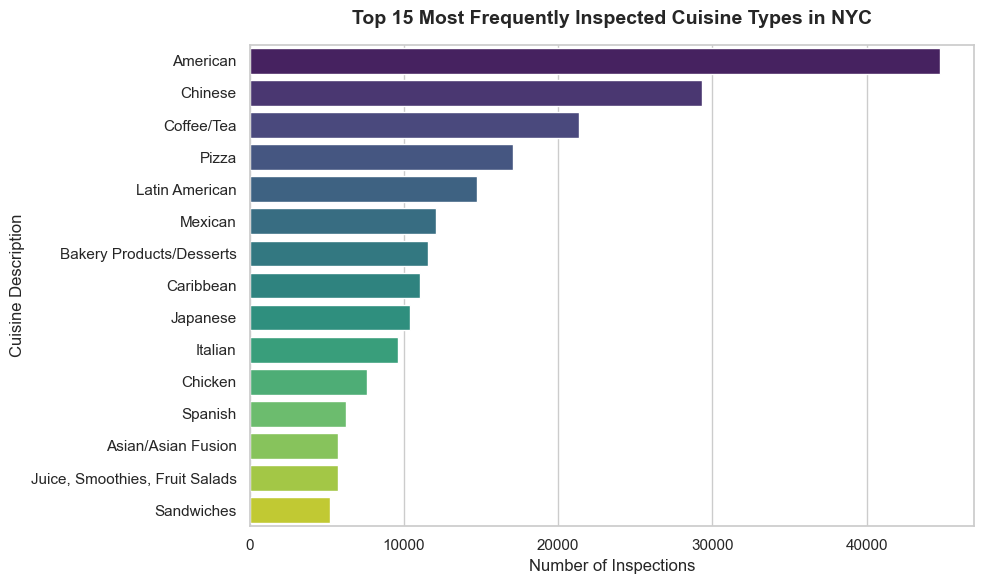

C:\Users\syedu\AppData\Local\Temp\ipykernel_19088\1013765887.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='BORO', y='SCORE', palette="Set3", ax=ax6)


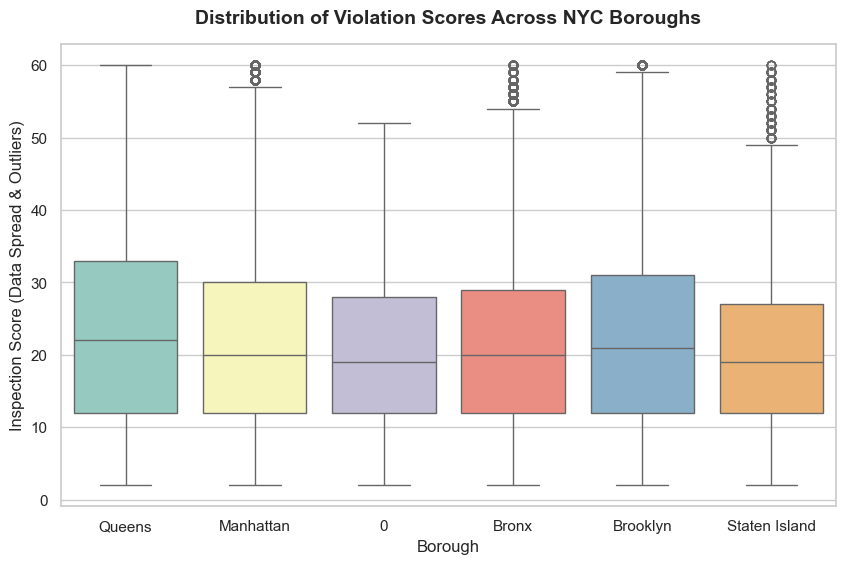

In [30]:
# --- CHART 4: BAR CHART (Top 15 Cuisines Inspected) ---
fig5, ax5 = plt.subplots(figsize=(10, 6))

# Grab the top 15 most frequent cuisines to avoid crowding the chart
top_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(15)

# Plotting horizontal bars makes long text labels much easier to read
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="viridis", ax=ax5)
ax5.set_title("Top 15 Most Frequently Inspected Cuisine Types in NYC", fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel("Number of Inspections", fontsize=12)
ax5.set_ylabel("Cuisine Description", fontsize=12)
plt.tight_layout() # Ensures labels don't get cut off at the edge
plt.show()

print("\n" + "="*50 + "\n") # Visual separator

# --- CHART 6: BOX PLOT (Borough vs. Violation Scores) ---
fig6, ax6 = plt.subplots(figsize=(10, 6))

# Filter out "Unknown" boroughs and restrict extreme scores for better visualization scale
box_df = df[(df['BORO'] != "Unknown") & (df['SCORE'] > 0) & (df['SCORE'] <= 60)]

sns.boxplot(data=box_df, x='BORO', y='SCORE', palette="Set3", ax=ax6)
ax6.set_title("Distribution of Violation Scores Across NYC Boroughs", fontsize=14, fontweight='bold', pad=15)
ax6.set_xlabel("Borough", fontsize=12)
ax6.set_ylabel("Inspection Score (Data Spread & Outliers)", fontsize=12)
plt.show()

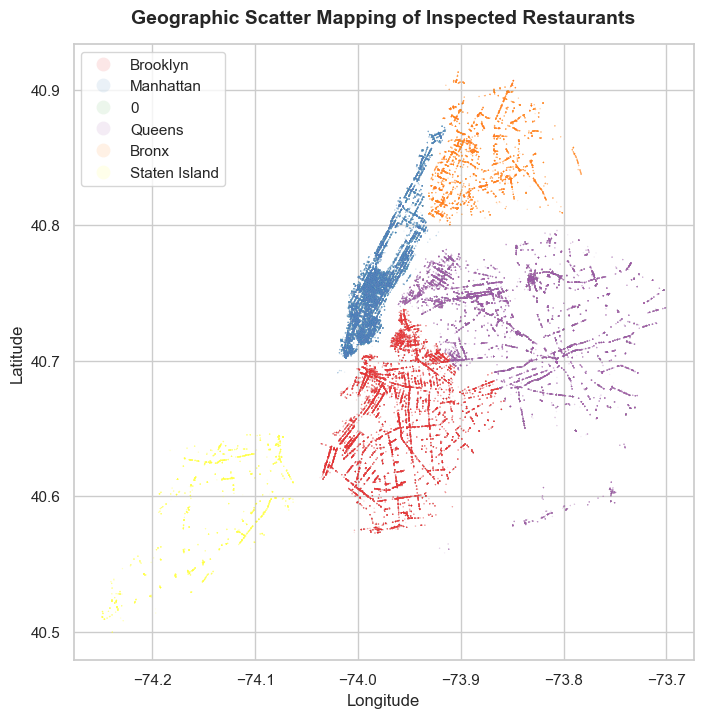

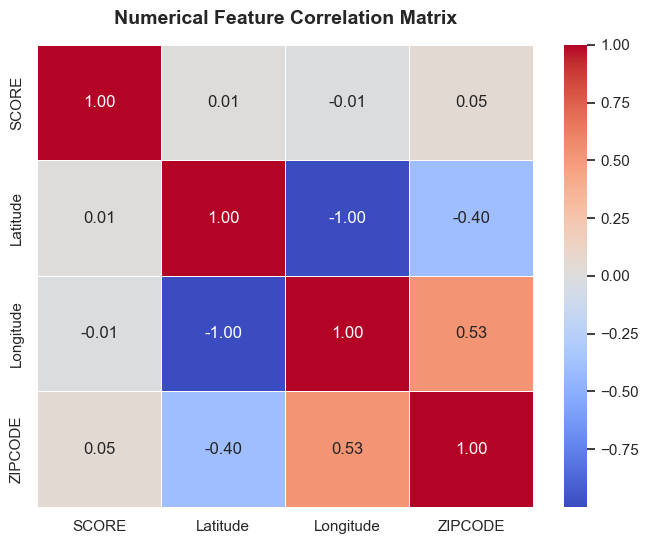

In [31]:
# --- CHART 5: SCATTER PLOT (Geographic Restaurant Map) ---
fig7, ax7 = plt.subplots(figsize=(8, 8))

# Filter out rows where coordinates are 0 or missing to avoid messing up the map scale
geo_df = df[(df['Longitude'] != 0) & (df['Latitude'] != 0) & (df['Longitude'] != "Unknown")]

# Converting coordinates to float just in case they were read as strings
geo_df['Longitude'] = geo_df['Longitude'].astype(float)
geo_df['Latitude'] = geo_df['Latitude'].astype(float)

# Using alpha=0.1 makes the points translucent so you can see density concentrations
sns.scatterplot(data=geo_df, x='Longitude', y='Latitude', hue='BORO', alpha=0.1, s=1, palette="Set1", ax=ax7)
ax7.set_title("Geographic Scatter Mapping of Inspected Restaurants", fontsize=14, fontweight='bold', pad=15)
ax7.set_xlabel("Longitude", fontsize=12)
ax7.set_ylabel("Latitude", fontsize=12)
ax7.legend(markerscale=10) # Makes the legend icons big enough to actually see
plt.show()

print("\n" + "="*50 + "\n") # Visual separator

# --- CHART 7: HEATMAP (Correlation Matrix) ---
fig8, ax8 = plt.subplots(figsize=(8, 6))

# Select only clean, purely numeric columns for the correlation computation
numeric_cols = df[['SCORE', 'Latitude', 'Longitude', 'ZIPCODE']].apply(pd.to_numeric, errors='coerce')
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax8)
ax8.set_title("Numerical Feature Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
plt.show()

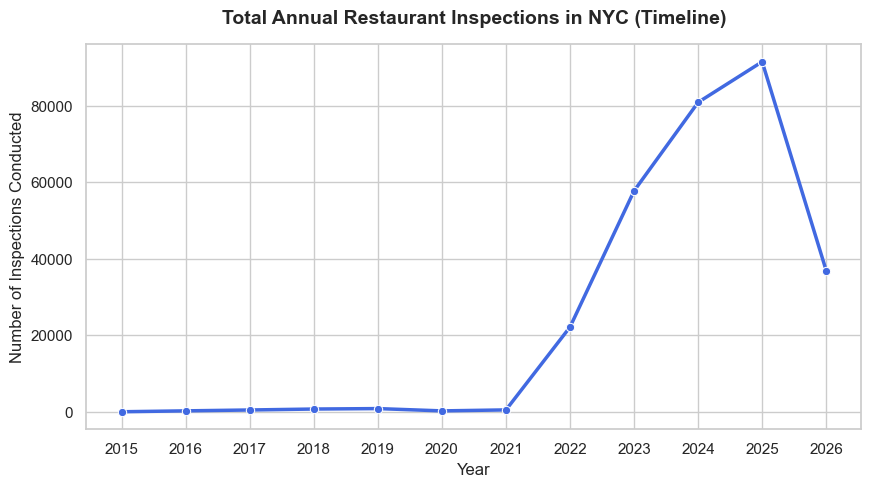

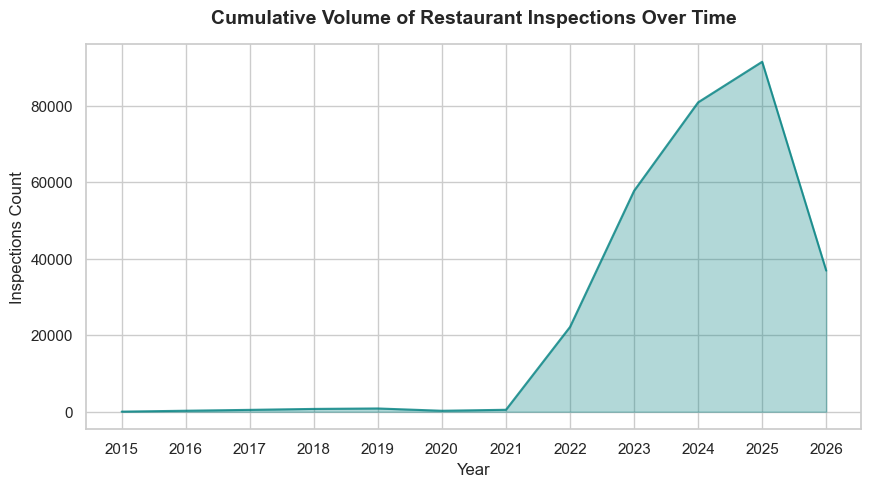

In [34]:
# --- PREPARATION FOR TIME-SERIES CHARTS ---

# 1. Force conversion back to datetime, turning any "Unknown" text into a safe NaT (Not a Time) value
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')

# 2. Extract the Year (this will now work perfectly since the column is datetimelike!)
df['Year'] = df['INSPECTION DATE'].dt.year

# 3. Filter out rows where the date was missing/corrupted, and restrict to valid years
timeline_df = df[df['Year'].notna()]  # Drops rows that couldn't be turned into dates
timeline_df = timeline_df[(timeline_df['Year'] >= 2015) & (timeline_df['Year'] <= 2026)]

# Ensure Year is read as a clean integer instead of a float
timeline_df['Year'] = timeline_df['Year'].astype(int)

# Group by year to get total counts
yearly_counts = timeline_df.groupby('Year').size()

# --- CHART 3: LINE CHART (Inspection Trends Over Time) ---
fig9, ax9 = plt.subplots(figsize=(10, 5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker="o", color="royalblue", linewidth=2.5, ax=ax9)

ax9.set_title("Total Annual Restaurant Inspections in NYC (Timeline)", fontsize=14, fontweight='bold', pad=15)
ax9.set_xlabel("Year", fontsize=12)
ax9.set_ylabel("Number of Inspections Conducted", fontsize=12)
ax9.set_xticks(yearly_counts.index)
plt.show()

print("\n" + "="*50 + "\n") # Visual separator

# --- CHART 8: AREA CHART (Cumulative Inspection Volume) ---
fig10, ax10 = plt.subplots(figsize=(10, 5))

ax10.plot(yearly_counts.index, yearly_counts.values, color="teal", alpha=0.8)
ax10.fill_between(yearly_counts.index, yearly_counts.values, color="teal", alpha=0.3)

ax10.set_title("Cumulative Volume of Restaurant Inspections Over Time", fontsize=14, fontweight='bold', pad=15)
ax10.set_xlabel("Year", fontsize=12)
ax10.set_ylabel("Inspections Count", fontsize=12)
ax10.set_xticks(yearly_counts.index)
plt.show()